<a href="https://colab.research.google.com/github/Wizako-01/A-Comparative-Study-of-Convolutional-Neural-Networks-and-ViT-for-Cervical-Cytology-Classification/blob/main/Stroke_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("fedesoriano/stroke-prediction-dataset")

print("Path to dataset files:", path)

100%|██████████| 67.4k/67.4k [00:00<00:00, 40.8MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/fedesoriano/stroke-prediction-dataset/versions/1


In [2]:
import pandas as pd

# Full path to the CSV
dataset_path = "/root/.cache/kagglehub/datasets/fedesoriano/stroke-prediction-dataset/versions/1/healthcare-dataset-stroke-data.csv"

# Load the data
data = pd.read_csv(dataset_path)

# Check first 5 rows
data.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [4]:

data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


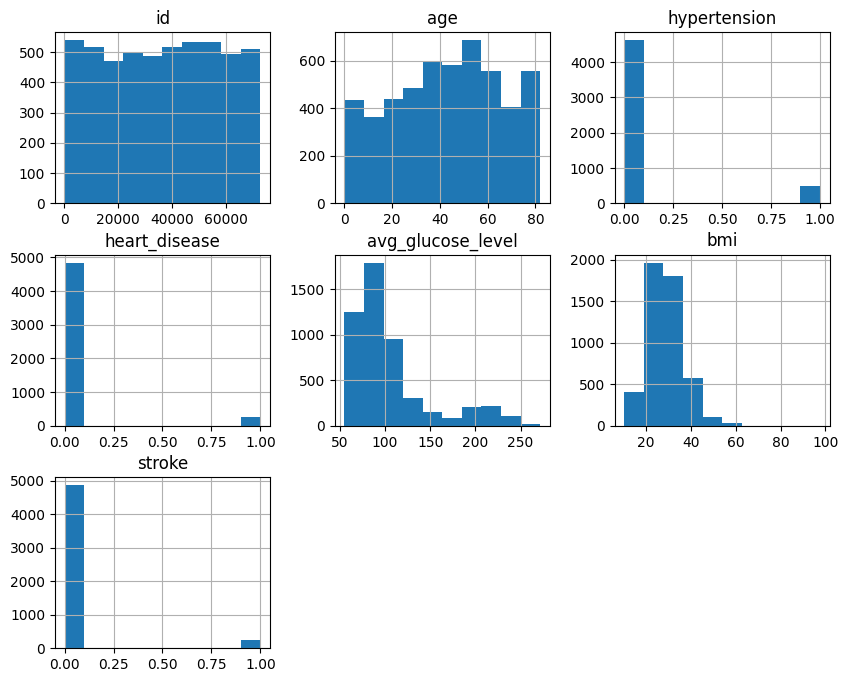

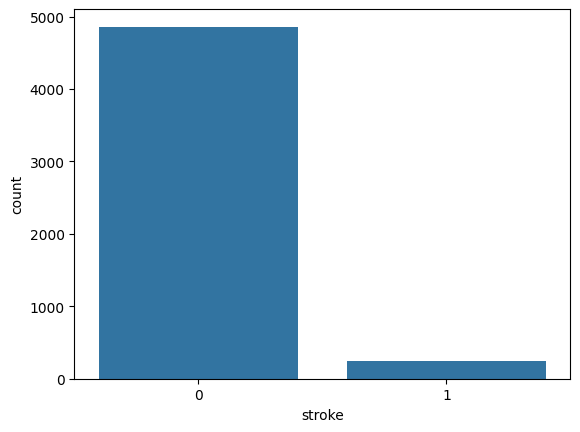

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Missing values
print(data.isnull().sum())

# Histogram for numeric features
data.hist(figsize=(10,8))
plt.show()

# Countplot for categorical features
sns.countplot(x="stroke", data=data)
plt.show()

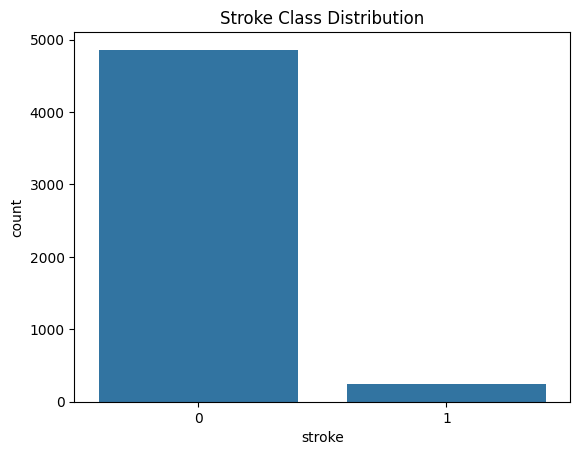

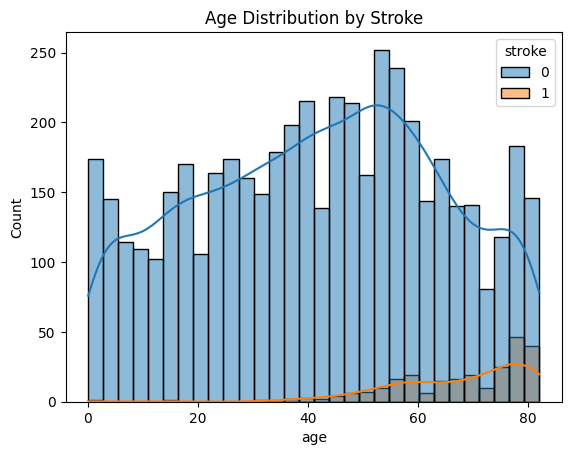

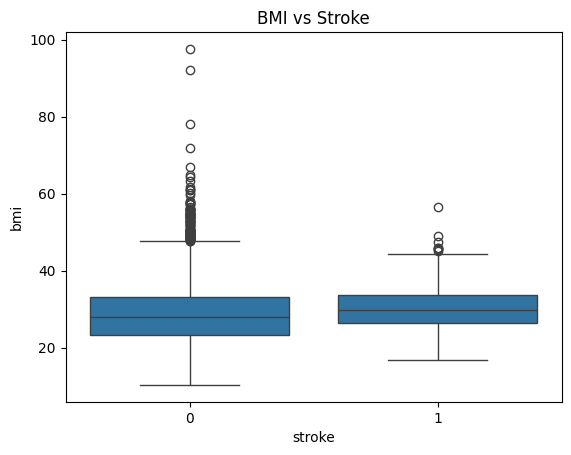

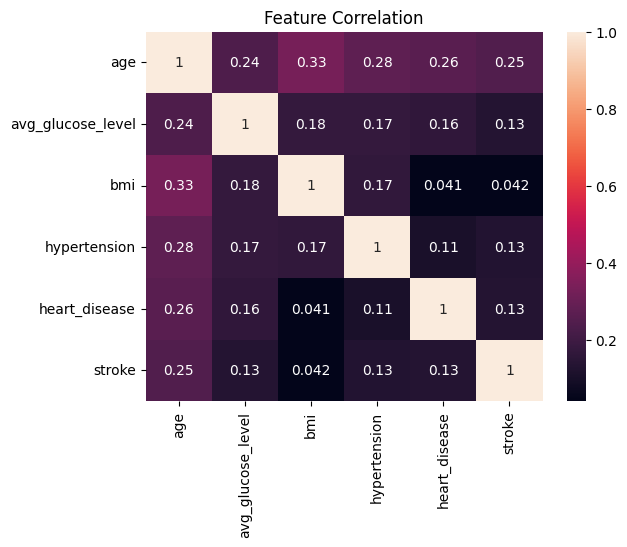

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Stroke distribution
sns.countplot(x='stroke', data=data)
plt.title("Stroke Class Distribution")
plt.show()

# Age distribution by stroke
sns.histplot(data=data, x='age', hue='stroke', bins=30, kde=True)
plt.title("Age Distribution by Stroke")
plt.show()

# BMI vs Stroke
sns.boxplot(x='stroke', y='bmi', data=data)
plt.title("BMI vs Stroke")
plt.show()

# Correlation heatmap for numeric features
numeric_cols = ['age', 'avg_glucose_level', 'bmi', 'hypertension', 'heart_disease']
sns.heatmap(data[numeric_cols + ['stroke']].corr(), annot=True)
plt.title("Feature Correlation")
plt.show()

First 5 rows:


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   object 
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   object 
 5   work_type          5110 non-null   object 
 6   Residence_type     5110 non-null   object 
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   object 
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 439.3+ KB

Missing values per column:
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_ty

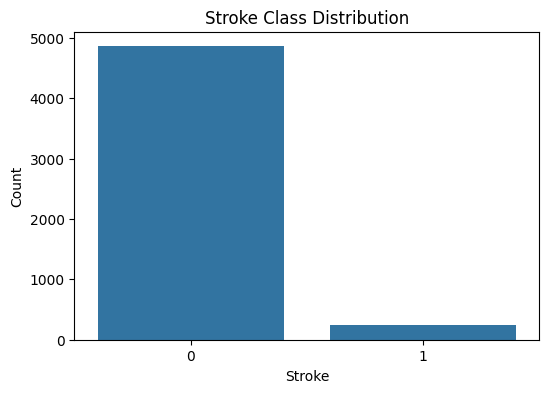

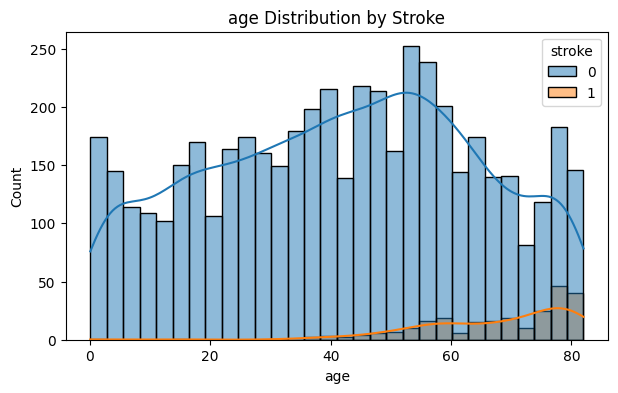

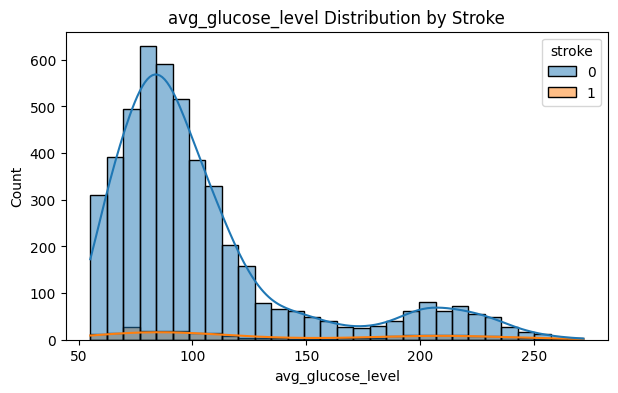

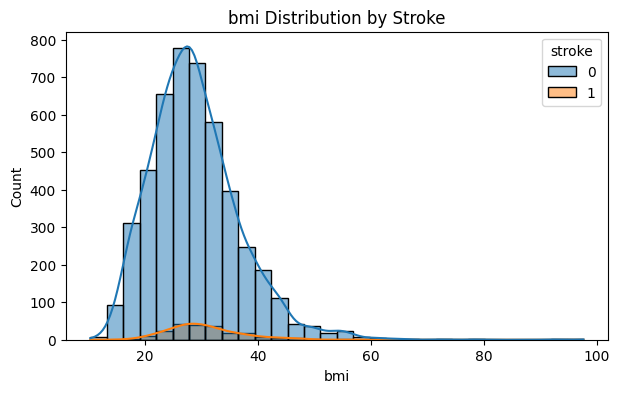

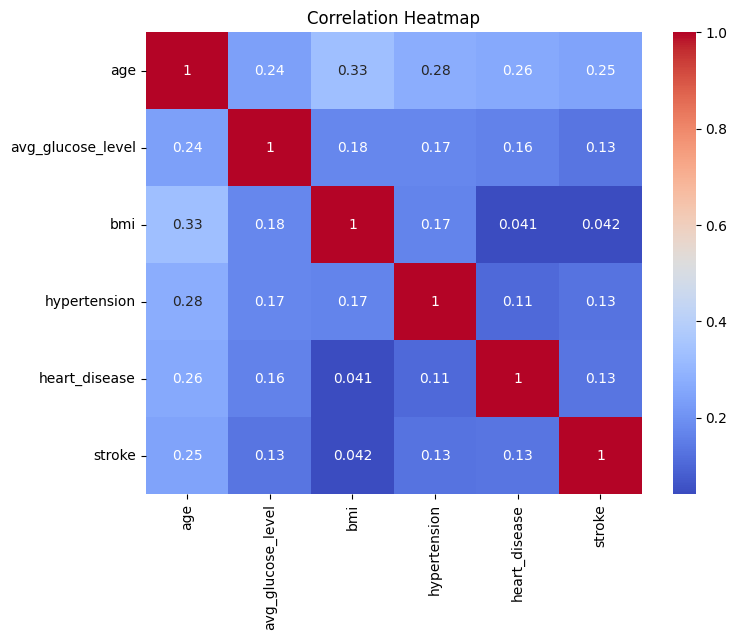


Cleaned data preview:


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,67.0,0,1,1,2,1,228.69,36.6,1,1
1,0,61.0,0,0,1,3,0,202.21,28.1,2,1
2,1,80.0,0,1,1,2,0,105.92,32.5,2,1
3,0,49.0,0,0,1,2,1,171.23,34.4,3,1
4,0,79.0,1,0,1,3,0,174.12,24.0,2,1



Class distribution before SMOTE:
stroke
0    3889
1     199
Name: count, dtype: int64

Class distribution after SMOTE:
stroke
0    3889
1    3889
Name: count, dtype: int64

Accuracy: 0.9021526418786693
Recall (Stroke): 0.18

Confusion Matrix:
[[913  59]
 [ 41   9]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       972
           1       0.13      0.18      0.15        50

    accuracy                           0.90      1022
   macro avg       0.54      0.56      0.55      1022
weighted avg       0.92      0.90      0.91      1022


Feature Importance:


,Feature,Importance
1,age,0.426056
7,avg_glucose_level,0.187903
8,bmi,0.148972
5,work_type,0.076404
9,smoking_status,0.053588
6,Residence_type,0.029303
0,gender,0.024936
4,ever_married,0.023637
2,hypertension,0.015595
3,heart_disease,0.013606


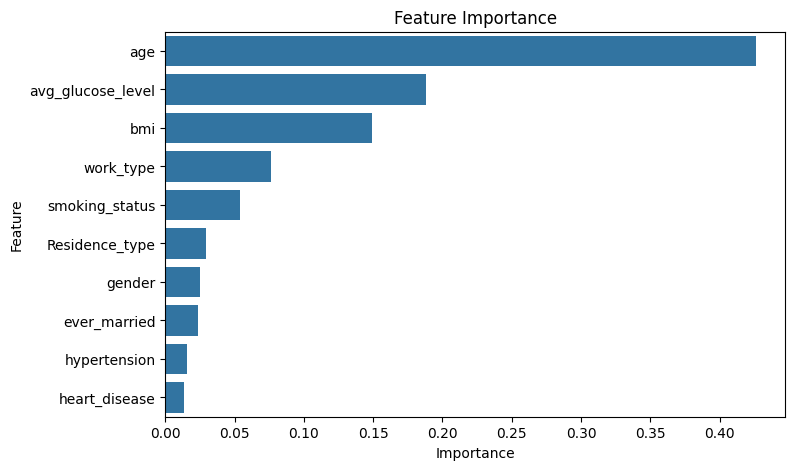


Model saved as stroke_model.pkl
Encoders saved as label_encoders.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
# =========================================
# 1. Import Libraries
# =========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, recall_score
from imblearn.over_sampling import SMOTE

# =========================================
# 2. Load Dataset
# =========================================
dataset_path = "/root/.cache/kagglehub/datasets/fedesoriano/stroke-prediction-dataset/versions/1/healthcare-dataset-stroke-data.csv"
data = pd.read_csv(dataset_path)

# Drop ID column
data = data.drop("id", axis=1)

print("First 5 rows:")
display(data.head())

print("\nDataset info:")
data.info()

print("\nMissing values per column:")
print(data.isnull().sum())

# =========================================
# 3. Visualize Data
# =========================================

# Stroke class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x="stroke", data=data)
plt.title("Stroke Class Distribution")
plt.xlabel("Stroke")
plt.ylabel("Count")
plt.show()

# Numeric feature distributions by stroke
numeric_cols = ["age", "avg_glucose_level", "bmi"]

for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=data, x=col, hue="stroke", bins=30, kde=True)
    plt.title(f"{col} Distribution by Stroke")
    plt.show()

# Correlation heatmap
plt.figure(figsize=(8, 6))
corr = data[["age", "avg_glucose_level", "bmi", "hypertension", "heart_disease", "stroke"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# =========================================
# 4. Clean Data
# =========================================

# Fill missing BMI values with median
data["bmi"] = data["bmi"].fillna(data["bmi"].median())

# Encode categorical columns
cat_cols = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]

label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

print("\nCleaned data preview:")
display(data.head())

# =========================================
# 5. Split Features and Target
# =========================================
X = data.drop("stroke", axis=1)
y = data["stroke"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nClass distribution before SMOTE:")
print(y_train.value_counts())

# =========================================
# 6. Apply SMOTE to Training Data
# =========================================
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("\nClass distribution after SMOTE:")
print(pd.Series(y_train_resampled).value_counts())

# =========================================
# 7. Train Random Forest Model
# =========================================
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train_resampled, y_train_resampled)

# =========================================
# 8. Evaluate Model
# =========================================
y_pred = model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("Recall (Stroke):", recall_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# =========================================
# 9. Feature Importance
# =========================================
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:")
display(feature_importance)

plt.figure(figsize=(8, 5))
sns.barplot(data=feature_importance, x="Importance", y="Feature")
plt.title("Feature Importance")
plt.show()

# =========================================
# 10. Save Model
# =========================================
joblib.dump(model, "stroke_model.pkl")
print("\nModel saved as stroke_model.pkl")

# Save encoders too, so you can use them later in Streamlit
joblib.dump(label_encoders, "label_encoders.pkl")
print("Encoders saved as label_encoders.pkl")

# =========================================
# 11. Download Files
# =========================================
from google.colab import files
files.download("stroke_model.pkl")
files.download("label_encoders.pkl")

First 5 rows:


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   object 
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   object 
 5   work_type          5110 non-null   object 
 6   Residence_type     5110 non-null   object 
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   object 
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 439.3+ KB

Missing values per column:
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_ty

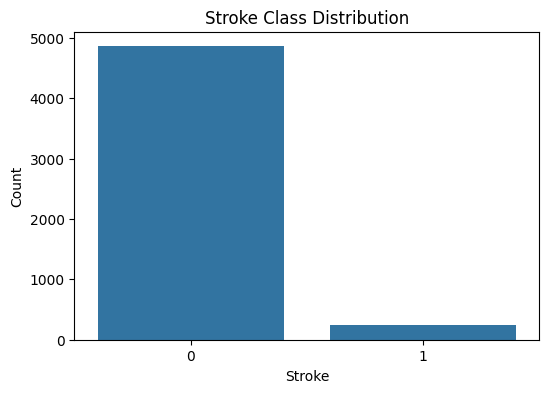

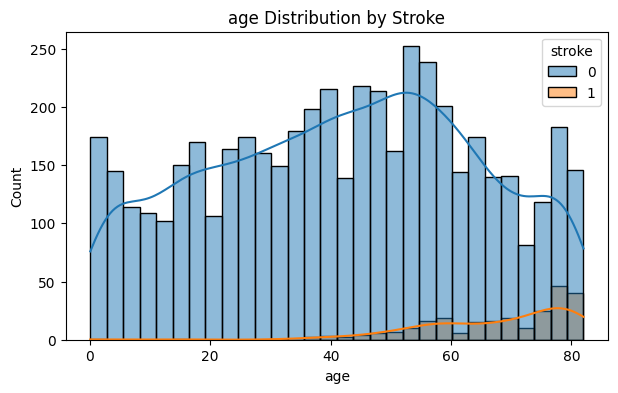

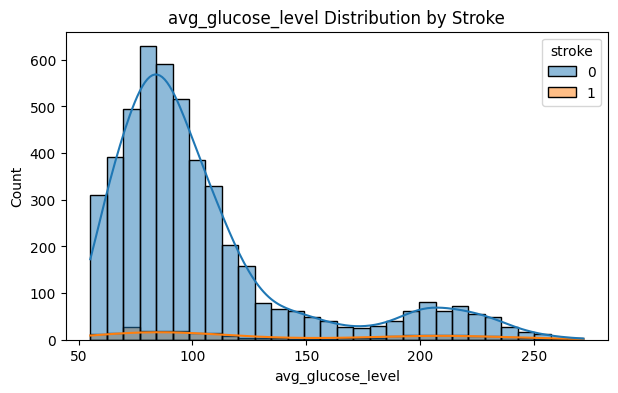

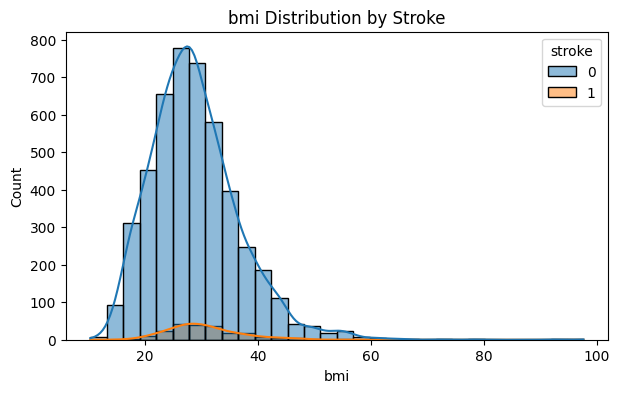

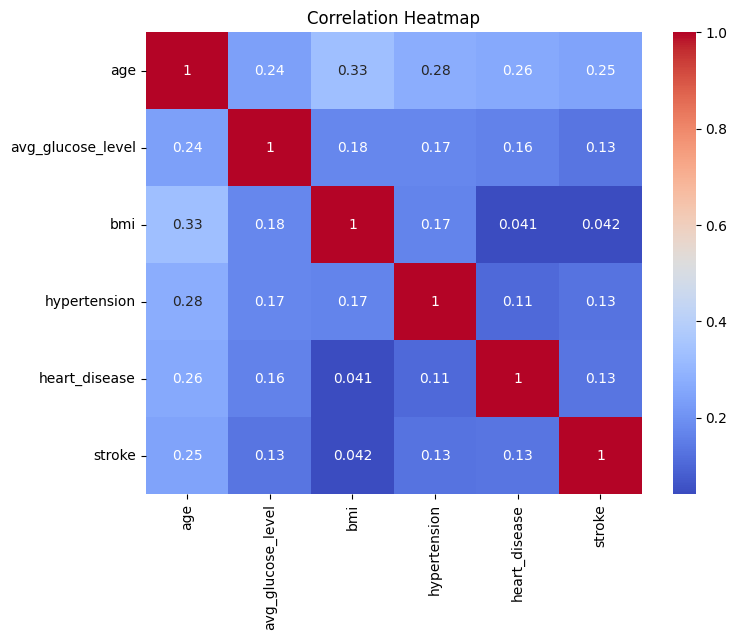


Cleaned data preview:


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,67.0,0,1,1,2,1,228.69,36.6,1,1
1,0,61.0,0,0,1,3,0,202.21,28.1,2,1
2,1,80.0,0,1,1,2,0,105.92,32.5,2,1
3,0,49.0,0,0,1,2,1,171.23,34.4,3,1
4,0,79.0,1,0,1,3,0,174.12,24.0,2,1



Training set class distribution:
stroke
0    3889
1     199
Name: count, dtype: int64

Test set class distribution:
stroke
0    972
1     50
Name: count, dtype: int64

===== Logistic Regression (Threshold = 0.5 Default) =====
Accuracy: 0.7524461839530333
Precision (Stroke): 0.1413427561837456
Recall (Stroke): 0.8

Confusion Matrix:
[[729 243]
 [ 10  40]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.75      0.85       972
           1       0.14      0.80      0.24        50

    accuracy                           0.75      1022
   macro avg       0.56      0.78      0.55      1022
weighted avg       0.95      0.75      0.82      1022


===== Threshold Comparison =====

Threshold = 0.5
Accuracy: 0.7524461839530333
Precision (Stroke): 0.1413427561837456
Recall (Stroke): 0.8
Confusion Matrix:
[[729 243]
 [ 10  40]]

Threshold = 0.4
Accuracy: 0.6829745596868885
Precision (Stroke): 0.11731843575418995
Recall (Stroke): 0.84
Co

,Feature,Coefficient
2,hypertension,0.544583
3,heart_disease,0.319707
6,Residence_type,0.145561
1,age,0.078326
9,smoking_status,0.021844
7,avg_glucose_level,0.004494
8,bmi,0.003794
5,work_type,-0.028904
0,gender,-0.060224
4,ever_married,-0.129995


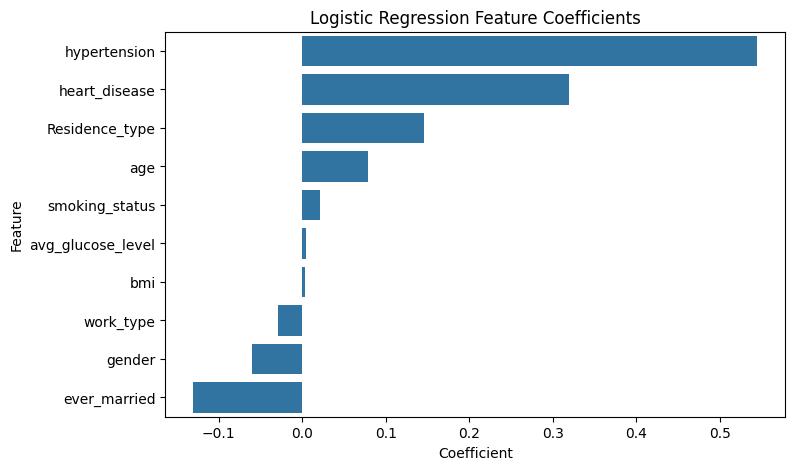


Saved files:
- stroke_logistic_model.pkl
- label_encoders.pkl
- threshold.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
# =========================================
# 1. Import Libraries
# =========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    recall_score,
    precision_score
)

# =========================================
# 2. Load Dataset
# =========================================
dataset_path = "/root/.cache/kagglehub/datasets/fedesoriano/stroke-prediction-dataset/versions/1/healthcare-dataset-stroke-data.csv"
data = pd.read_csv(dataset_path)

# Drop ID column
data = data.drop("id", axis=1)

print("First 5 rows:")
display(data.head())

print("\nDataset info:")
data.info()

print("\nMissing values per column:")
print(data.isnull().sum())

# =========================================
# 3. Visualize Data
# =========================================

# Stroke class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x="stroke", data=data)
plt.title("Stroke Class Distribution")
plt.xlabel("Stroke")
plt.ylabel("Count")
plt.show()

# Numeric feature distributions
numeric_cols = ["age", "avg_glucose_level", "bmi"]

for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=data, x=col, hue="stroke", bins=30, kde=True)
    plt.title(f"{col} Distribution by Stroke")
    plt.show()

# Correlation heatmap
plt.figure(figsize=(8, 6))
corr = data[["age", "avg_glucose_level", "bmi", "hypertension", "heart_disease", "stroke"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# =========================================
# 4. Clean and Encode Data
# =========================================

# Fill missing BMI values with median
data["bmi"] = data["bmi"].fillna(data["bmi"].median())

# Encode categorical columns
cat_cols = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]

label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

print("\nCleaned data preview:")
display(data.head())

# =========================================
# 5. Split Features and Target
# =========================================
X = data.drop("stroke", axis=1)
y = data["stroke"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTraining set class distribution:")
print(y_train.value_counts())

print("\nTest set class distribution:")
print(y_test.value_counts())

# =========================================
# 6. Train Logistic Regression Model
# =========================================
log_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train, y_train)

# =========================================
# 7. Evaluate at Default Threshold
# =========================================
y_pred_default = log_model.predict(X_test)

print("\n===== Logistic Regression (Threshold = 0.5 Default) =====")
print("Accuracy:", accuracy_score(y_test, y_pred_default))
print("Precision (Stroke):", precision_score(y_test, y_pred_default, zero_division=0))
print("Recall (Stroke):", recall_score(y_test, y_pred_default))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_default))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_default, zero_division=0))

# =========================================
# 8. Threshold Optimization
# =========================================
y_proba = log_model.predict_proba(X_test)[:, 1]

thresholds = [0.5, 0.4, 0.3]

best_threshold = None
best_recall = -1
best_precision = 0
best_predictions = None

print("\n===== Threshold Comparison =====")

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    acc = accuracy_score(y_test, y_pred_t)
    prec = precision_score(y_test, y_pred_t, zero_division=0)
    rec = recall_score(y_test, y_pred_t)
    cm = confusion_matrix(y_test, y_pred_t)

    print(f"\nThreshold = {t}")
    print("Accuracy:", acc)
    print("Precision (Stroke):", prec)
    print("Recall (Stroke):", rec)
    print("Confusion Matrix:")
    print(cm)

    # Pick the threshold with the highest recall
    # If recall ties, prefer the one with better precision
    if rec > best_recall or (rec == best_recall and prec > best_precision):
        best_recall = rec
        best_precision = prec
        best_threshold = t
        best_predictions = y_pred_t

# =========================================
# 9. Final Evaluation Using Best Threshold
# =========================================
print("\n===== BEST MODEL =====")
print("Best Threshold:", best_threshold)
print("Best Recall:", best_recall)
print("Best Precision:", best_precision)
print("Best Accuracy:", accuracy_score(y_test, best_predictions))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, best_predictions))

print("\nClassification Report:")
print(classification_report(y_test, best_predictions, zero_division=0))

# =========================================
# 10. Logistic Regression Coefficients
# =========================================
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

print("\nLogistic Regression Coefficients:")
display(coef_df)

plt.figure(figsize=(8, 5))
sns.barplot(data=coef_df, x="Coefficient", y="Feature")
plt.title("Logistic Regression Feature Coefficients")
plt.show()

# =========================================
# 11. Save Model, Encoders, and Best Threshold
# =========================================
joblib.dump(log_model, "stroke_logistic_model.pkl")
joblib.dump(label_encoders, "label_encoders.pkl")

with open("threshold.json", "w") as f:
    json.dump({"threshold": best_threshold}, f)

print("\nSaved files:")
print("- stroke_logistic_model.pkl")
print("- label_encoders.pkl")
print("- threshold.json")

# =========================================
# 12. Download Files in Colab
# =========================================
from google.colab import files
files.download("stroke_logistic_model.pkl")
files.download("label_encoders.pkl")
files.download("threshold.json")

In [12]:
import streamlit as st
import joblib
import json
import numpy as np

# Load saved files
model = joblib.load("stroke_logistic_model.pkl")
label_encoders = joblib.load("label_encoders.pkl")

with open("threshold.json", "r") as f:
    threshold = json.load(f)["threshold"]

st.title("Stroke Risk Prediction App")
st.write("Enter patient information to estimate stroke risk.")

# User inputs
gender = st.selectbox("Gender", ["Male", "Female", "Other"])
age = st.number_input("Age", min_value=0.0, max_value=120.0, value=50.0)
hypertension = st.selectbox("Hypertension", [0, 1])
heart_disease = st.selectbox("Heart Disease", [0, 1])
ever_married = st.selectbox("Ever Married", ["Yes", "No"])
work_type = st.selectbox("Work Type", ["Private", "Self-employed", "Govt_job", "children", "Never_worked"])
residence_type = st.selectbox("Residence Type", ["Urban", "Rural"])
avg_glucose_level = st.number_input("Average Glucose Level", min_value=0.0, value=100.0)
bmi = st.number_input("BMI", min_value=0.0, value=25.0)
smoking_status = st.selectbox("Smoking Status", ["formerly smoked", "never smoked", "smokes", "Unknown"])

# Encode categorical inputs
gender_encoded = label_encoders["gender"].transform([gender])[0]
ever_married_encoded = label_encoders["ever_married"].transform([ever_married])[0]
work_type_encoded = label_encoders["work_type"].transform([work_type])[0]
residence_type_encoded = label_encoders["Residence_type"].transform([residence_type])[0]
smoking_status_encoded = label_encoders["smoking_status"].transform([smoking_status])[0]

# Prediction
if st.button("Predict Stroke Risk"):
    input_data = np.array([[
        gender_encoded,
        age,
        hypertension,
        heart_disease,
        ever_married_encoded,
        work_type_encoded,
        residence_type_encoded,
        avg_glucose_level,
        bmi,
        smoking_status_encoded
    ]])

    probability = model.predict_proba(input_data)[0][1]
    prediction = int(probability >= threshold)

    st.subheader("Result")
    st.write(f"Predicted probability of stroke: {probability:.2f}")
    st.write(f"Decision threshold: {threshold}")

    if prediction == 1:
        st.error("High Stroke Risk")
    else:
        st.success("Low Stroke Risk")

    st.caption("This tool is for educational purposes only and not for clinical diagnosis.")

ModuleNotFoundError: No module named 'streamlit'